In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_final = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\archive\LOCMM_08062025_DATASET_VITAMINd.csv')

In [3]:
threshold = 1e-10

# Select numeric columns
numeric_cols = df_final.select_dtypes(include='number').columns

# Apply threshold replacement only on numeric columns
df_final[numeric_cols] = df_final[numeric_cols].applymap(
    lambda x: 0 if abs(x) < threshold else x
)



C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\2557628910.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final[numeric_cols] = df_final[numeric_cols].applymap(


In [4]:
# # === Step 1: Create label from VitaminD ===
# def assign_label(x):
#     if pd.isna(x):
#         return None
#     elif x < 50:
#         return 0
#     elif x >= 50 and x < 125:
#         return 1
#     else:
#         return 2

# df_final['label'] = df_final['VitaminD'].apply(assign_label)

# === Bước 2: Trích năm đầu tiên từ chuỗi "2001-2002" ===
# df_final['YearStart'] = df_final['YearID'].astype(str).str.extract(r'(\d{4})').astype(int)
# Tách năm bắt đầu thành cột số nguyên để dễ xử lý
df_final['YearStart'] = df_final['YearID'].str[:4].astype(int)

# # Xử lý cho dữ liệu từ 2001–2012
# df1 = df_final[df_final['YearStart'] < 2013].copy()
# df1.loc[df1['SmokeFam'] == 2, 'SmokeFam'] = 1
# df1 = df1[df1['SmokeFam'] <= 1]

# # Xử lý cho dữ liệu từ 2013 trở đi
# df2 = df_final[df_final['YearStart'] >= 2013].copy()
# df2.loc[(df2['SmokeFam'] >= 1.0) & (df2['SmokeFam'] <= 3.0), 'SmokeFam'] = 1
# df2 = df2[df2['SmokeFam'] <= 1]
# df_final = pd.concat([df1,df2])

def binary_vitamin_d_label(row):
    val = row['VitaminD']
    year = row['YearStart']

    if pd.isna(val) or pd.isna(year):
        return None  # hoặc np.nan

    if year in [2001, 2003]:
        return 1 if val < 20 else 0
    else:
        return 1 if val < 50 else 0

df_final['label'] = df_final.apply(binary_vitamin_d_label, axis=1)

# === Bước 3: Tách dữ liệu theo mốc năm 2013 ===
df_final_train = df_final[df_final['YearStart'] <= 2013]
df_final_train['VitaminD'].fillna(df_final_train['VitaminD'].median(numeric_only=True), inplace=True)
df_final_train['label'] = df_final_train.apply(binary_vitamin_d_label, axis=1)
df_final_test = df_final[df_final['YearStart'] > 2013]
df_final_test['label'] = df_final_test.apply(binary_vitamin_d_label, axis=1)

# === Bước 4: Ghi ra file CSV ===
df_final_train.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\train.csv', index=False)
df_final_test.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\test.csv', index=False)

# === Log số dòng để xác nhận ===
print(f"✅ Số dòng train: {len(df_final_train)} được lưu vào train.csv")
print(f"✅ Số dòng test : {len(df_final_test)} được lưu vào test.csv")


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\708142459.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final_train['VitaminD'].fillna(df_final_train['VitaminD'].median(numeric_only=True), inplace=True)
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\708142459.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fina

✅ Số dòng train: 23838 được lưu vào train.csv
✅ Số dòng test : 6227 được lưu vào test.csv


In [5]:
# Read files train
df = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\train.csv')
df_test = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\test.csv')

In [6]:
df_test['SmokeFam'].value_counts()

SmokeFam
0.0      2605
1.0       806
2.0       368
3.0        94
999.0       5
777.0       1
Name: count, dtype: int64

In [7]:
df['SmokeFam'] = df.apply(
    lambda row: 0 if row['SmokeFam'] == 2 and int(row['YearStart']) <= 2011 else 1,
    axis=1
)

In [8]:
df_test['SmokeFam'] = df_test.apply(
    lambda row: 0 if row['SmokeFam'] == 0 else 1,
    axis=1
)

In [9]:
df_test['Hba1c'].isna().sum()

np.int64(347)

In [10]:
df_test.dropna(subset=['Hba1c'],inplace=True)

In [11]:
df.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\train.csv', index=False)
df_test.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\test.csv', index=False)

In [12]:
df['SmokeFam'].value_counts()

SmokeFam
0    16667
1     7171
Name: count, dtype: int64

In [13]:
df_test['SmokeFam'].value_counts()

SmokeFam
1    3392
0    2488
Name: count, dtype: int64

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\2101383360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


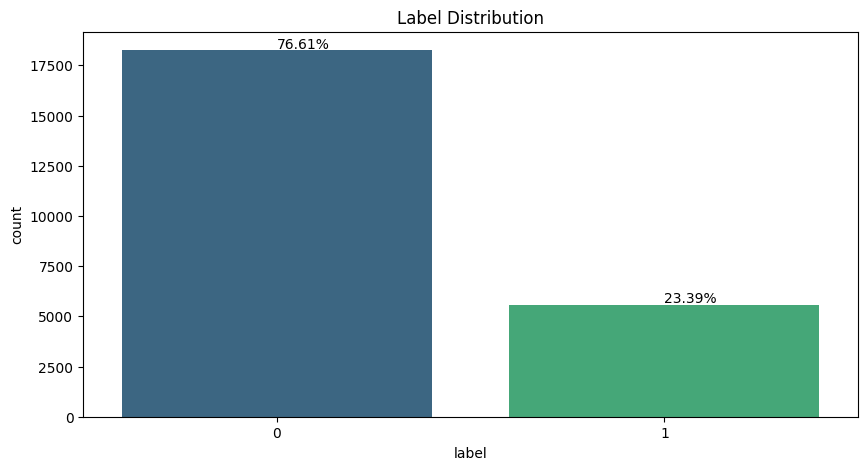

In [14]:
# Draw label distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')

plt.title('Label Distribution')
for i, rec in enumerate(ax.patches):
    ax.text(
        rec.get_x() + rec.get_width()/2,
        rec.get_height() + 100,
        f'{rec.get_height()/len(df)*100:.2f}%',
    )
plt.show()

### 1. Handle Missing value

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23838 entries, 0 to 23837
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      23838 non-null  float64
 1   Gender                    23838 non-null  float64
 2   Age                       23838 non-null  float64
 3   Race                      23838 non-null  float64
 4   familysize                23838 non-null  float64
 5   PIR                       22035 non-null  float64
 6   BMXWT                     23462 non-null  float64
 7   BMXHT                     23490 non-null  float64
 8   BMI                       23376 non-null  float64
 9   WaistCircumference        22722 non-null  float64
 10  FastingGlucose            22439 non-null  float64
 11  ALT                       22143 non-null  float64
 12  AST                       22140 non-null  float64
 13  AlkalinePhosphotase       22169 non-null  float64
 14  Choles

In [16]:
# Drop columns not used fully
cols_drop = [
    "SEQN", "HBsAg",
    "CreatinineUmol"
]

df.drop(columns=cols_drop, inplace=True)

In [17]:
def check_missing_ratio(df_check):
    ratio_completeness = []
    for column in df_check.columns:
        completeness_ratio = df_check[column].notnull().sum() / len(df_check)
        ratio_completeness.append(completeness_ratio)

    # Draw ratio
    plt.figure(figsize=(20, 10)) # type: ignore
    plt.title("Completeness Ratio")
    ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')

    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_x() + rec.get_width(),
            rec.get_y() + rec.get_height()/2,
            f'{ratio_completeness[i]:.2%}',
        )

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\1027853617.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')


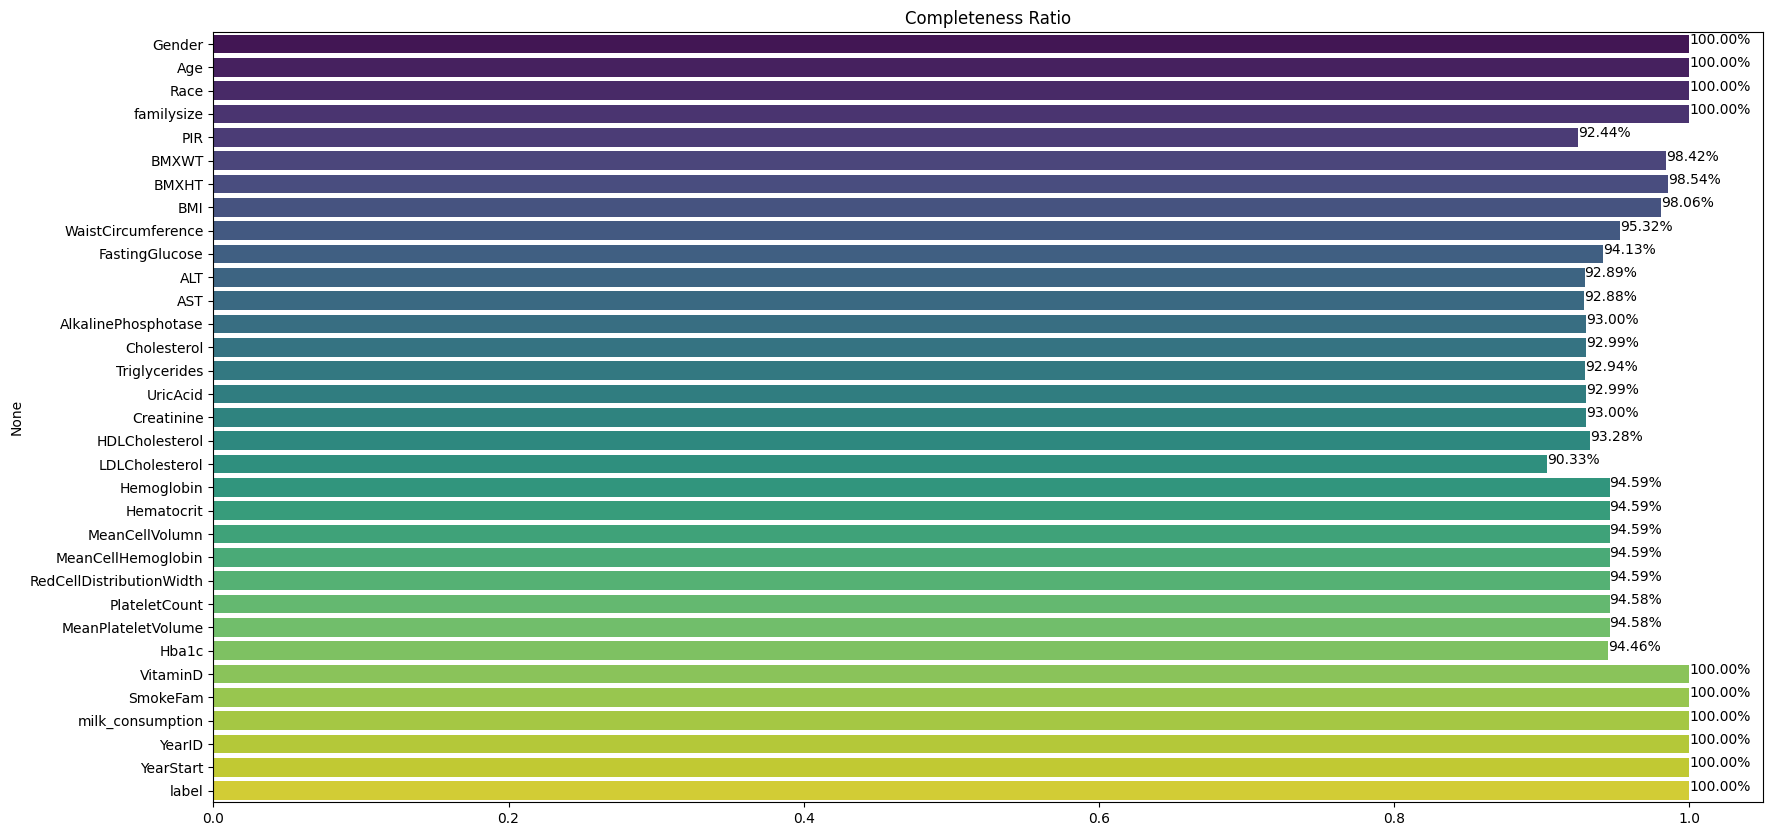

In [18]:
check_missing_ratio(df)

In [19]:
df.fillna(df.median(numeric_only=True), inplace=True)

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\1027853617.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')


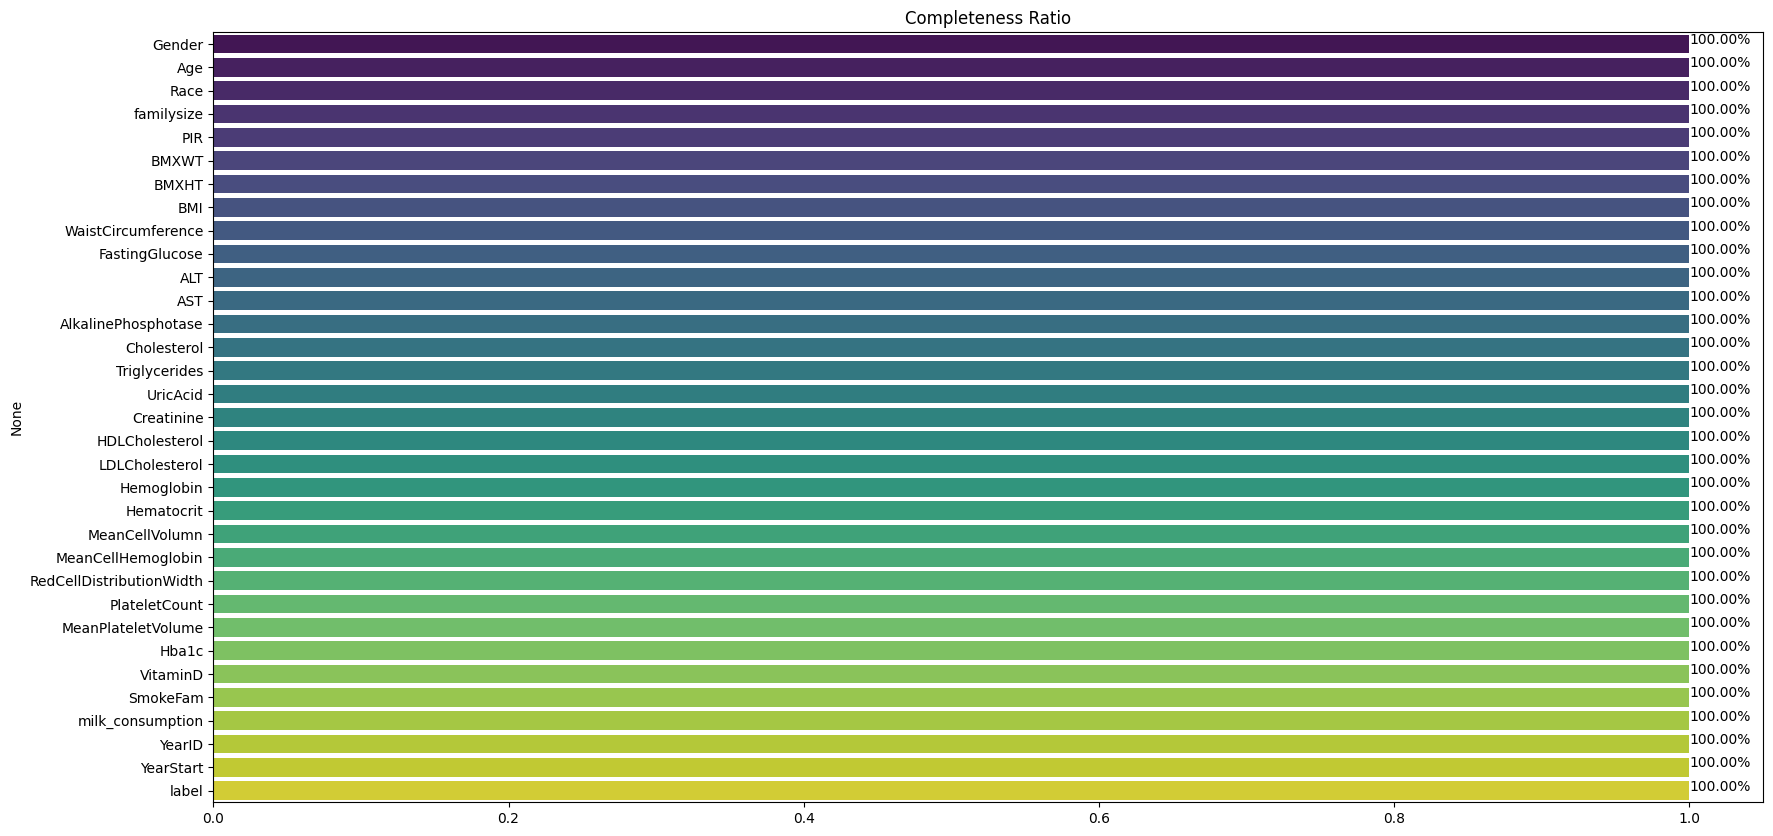

In [20]:
check_missing_ratio(df)

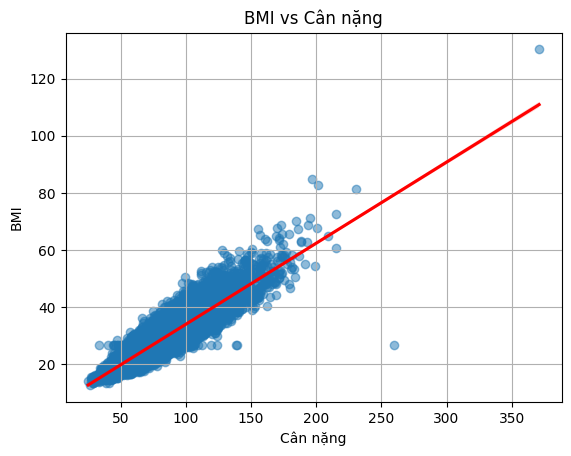

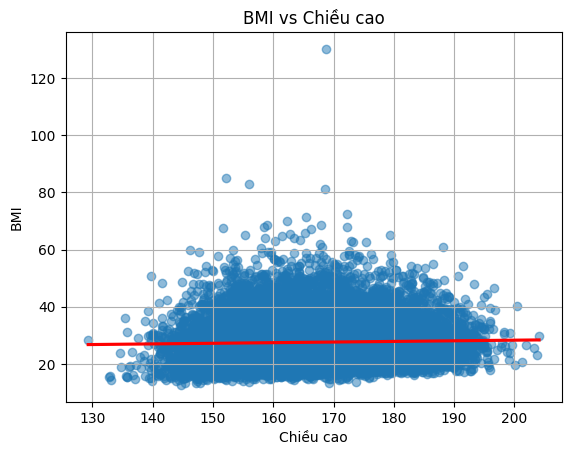

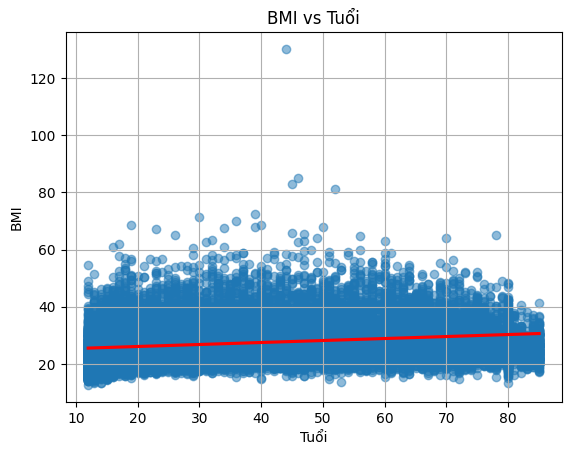

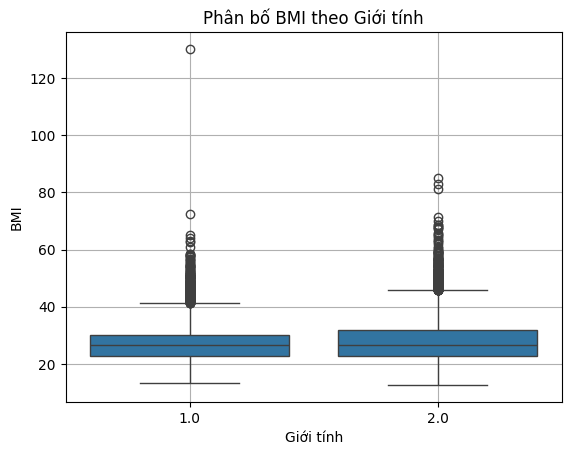

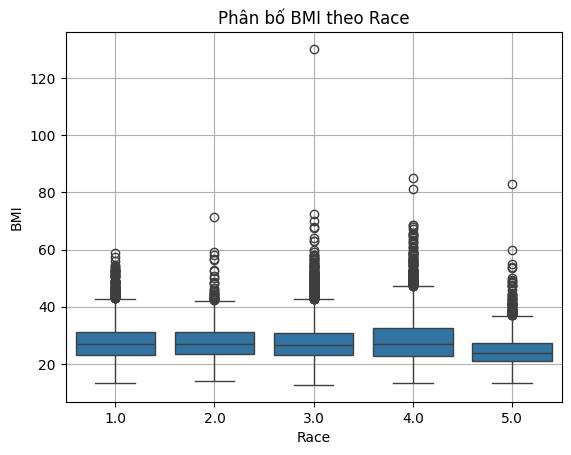

In [21]:
# Vòng eo vs BMI
sns.regplot(x='BMXWT', y='BMI', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('BMI vs Cân nặng')
plt.xlabel('Cân nặng')
plt.ylabel('BMI')
plt.grid(True)
plt.show()

# Vòng eo vs BMI
sns.regplot(x='BMXHT', y='BMI', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('BMI vs Chiều cao')
plt.xlabel('Chiều cao')
plt.ylabel('BMI')
plt.grid(True)
plt.show()

# Age vs BMI
if 'Age' in df.columns:
    sns.regplot(x='Age', y='BMI', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    plt.title('BMI vs Tuổi')
    plt.xlabel('Tuổi')
    plt.ylabel('BMI')
    plt.grid(True)
    plt.show()

# Gender vs BMI
if 'Gender' in df.columns:
    sns.boxplot(x='Gender', y='BMI', data=df)
    plt.title('Phân bố BMI theo Giới tính')
    plt.xlabel('Giới tính')
    plt.ylabel('BMI')
    plt.grid(True)
    plt.show()

# Race vs BMI
if 'Race' in df.columns:
    sns.boxplot(x='Race', y='BMI', data=df)
    plt.title('Phân bố BMI theo Race')
    plt.xlabel('Race')
    plt.ylabel('BMI')
    plt.grid(True)
    plt.show()

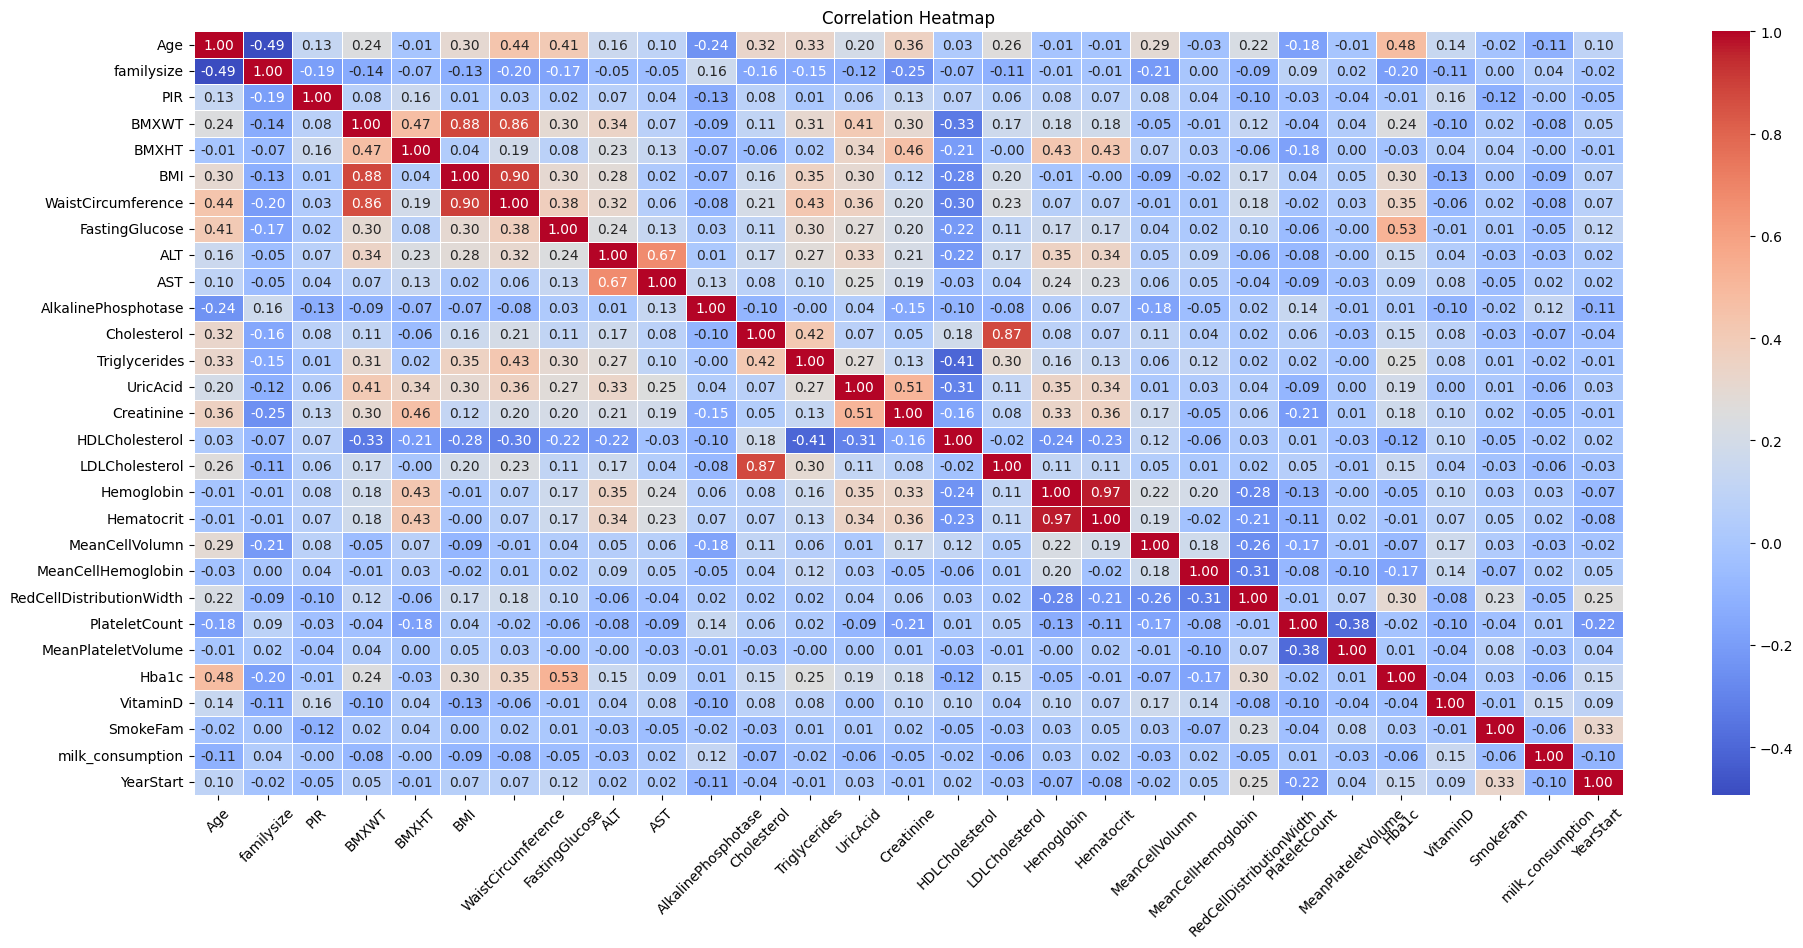

In [22]:
df_corr = df.copy()
df_corr.drop(columns=[
    "Gender", "Race", 
    "label", "YearID",
], inplace=True)

# Check consistency between columns with spearman correlation
correlation_matrix = df_corr.corr(method = "spearman")

plt.figure(figsize=(20, 10))  # Kích thước biểu đồ
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [23]:
# Imputation LDL cholesterol
for index, col in enumerate(['LDLCholesterol', 'HDLCholesterol', 'Triglycerides']):
    for i, row in df.iterrows():
        if pd.isnull(row[col]):
            TotalCholesterol = row['Cholesterol']
            a = ''
            b = ''
            c = 0
            if col == 'LDLCholesterol':
                a = row['HDLCholesterol']
                b = row['Triglycerides']
            elif col == 'HDLCholesterol':
                a = row['LDLCholesterol']
                b = row['Triglycerides']
            else:
                a = row['LDLCholesterol']
                b = row['HDLCholesterol']
            if pd.isnull(TotalCholesterol) or pd.isnull(a) or pd.isnull(b):
                    continue
            
            # Calculate LDL cholesterol using Friedewald formula
            if col == 'Triglycerides':
                c = (TotalCholesterol - a - b)*5
            else:
                c = TotalCholesterol - a - b/5
            df.loc[i, col] = c

In [24]:
columns_list = df.columns.tolist()

# remove WaistCircumference from columns_list
if 'WaistCircumference' in columns_list:
    columns_list.remove('WaistCircumference')

# drop null values
df.dropna(subset=columns_list, inplace=True)


### 2. Handle outlier

In [25]:
# Create dict to convert rate to measure
measures_dict = {
    "BMI": { # kg/m^2
        "both":{
            "1": 18.4, # <18.4
            "2": 24.9, # 18.4 <= x < 24.9
            "3": 30, # 24.9 <= x < 30
            "4": 30 # >= 30
        }
    },

    "WaistCircumference": {  # cm
        "male":{
            "1": 94, # <94
            "2": 102, # 94 <= x < 102
            "3": 102, # >= 102
        }, 
        "female": {
            "1": 80, # <80
            "2": 88, # 80 <= x < 88
            "3": 88 # >= 88
        }
    },

    "HDLCholesterol": { # mg/dl
        "both":{
            "1": 40, # <40
            "2": 60, # 40 <= x < 60
            "3": 60 # >= 60
        }  
    },

    "Triglycerides":{ # mg/dl
        "both":{
            "1": 150, # <150
            "2": 200, # 150 <= x < 200
            "3": 200, # >= 200
        }
    },

    "LDLCholesterol": { # mg/dl
        "both":{
            "1": 100, # <100
            "2": 160, # 100 <= x < 160
            "3": 160 # >= 160
        }
    },

    "Hba1c": { # %
        "both":{
            "1": 5.7, # <5.7
            "2": 6.5, # 5.7 <= x < 6.5
            "3": 6.5 # >= 6.5
        }
    },

    "ALT": { # U/L
        "male": {
            "1": 0, # <0
            "2": 41, # 0 <= x < 41
            "3": 41 # >= 41
        },
        "female":{
            "1": 0, # <0
            "2": 32, # 0 <= x < 32
            "3": 32 # >= 31
        }
    },

    "AST": {  # U/L
        "male": {
            "1": 0, # <0
            "2": 38, # 0 <= x < 38
            "3": 38 # >= 40
        },
        "female":{
            "1": 0, # <0
            "2": 32, # 0 <= x < 32
            "3": 32 # >= 32
        }
    },

    "AlkalinePhosphotase":{ # U/L
        "male": {
            "1": 40, # < 40
            "2": 130, # 40 <= x < 130
            "3": 130 # >= 130
        },
        "female":{
            "1": 35, # < 35
            "2": 105, # 35 <= x < 105
            "3": 105 # >= 105
        }
    },

    "Creatinine":{  # mg/dl
        "male": {
            "1": 0.67, # <0.67
            "2": 1.18, # 0.67 <= x < 1.18,
            "3": 1.18 # >= 1.18
        },
        "female":{
            "1": 0.51, # < 0.51
            "2": 0.96, # 0.51 <= x < 0.96
            "3": 0.96 # >= 0.96
        }
    },
    
    "UricAcid": { # mng/dl
        "male": {
            "1": 3.4, # <3.4
            "2": 7.1, # 3.4 <= x < 7.1
            "3": 7.1 # >= 7.1
        }, 

        "female": {
            "1": 2.4, # < 2.4
            "2": 5.8, # 2.4 <= x < 5.8
            "3": 5.8 # >= 5.8
        }
    }
}

In [26]:
col_blood_dict = {
    "Hemoglobin": {
        "min": 10.7,
        "max": 17.1
    },
    "Hematocrit": {
        "min": 32.1,
        "max": 50.9
    },
    "MeanCellVolumn": {
        "min": 68.2,
        "max": 102.7
    },
    "MeanCellHemoglobin": {
        "min": 22.3,
        "max": 35
    },
    "RedCellDistributionWidth": {
        "min": 11.4,
        "max": 16.2
    },
    "PlateletCount": {
        "min": 155,
        "max": 547
    },
    "MeanPlateletVolume": {
        "min": 6.1,
        "max": 10.2
    }
}

In [27]:
# Drop outlier value
'''
   Strategy to check outlier:
    1. Use boxplot to visualize outliers
    2. Use Z-score to detect outliers
      2.1 If Z-score > 3 and greater than max normal range value => outlier
    3. Measure Consistency ratio
'''
          
def check_and_drop_outlier(df_check):
    df_dq = df_check.copy()
    for col in df_dq.columns:
        if col in measures_dict.keys():
          # Calculate Z-score of column
          z_score = (df_dq[col] - df_dq[col].mean()) / df_dq[col].std()
          max_value = 0
          min_value = 0
          if measures_dict[col].get("both"):
            # get max value and min value
            max_value = max(measures_dict[col]["both"].values())
            min_value = min(measures_dict[col]["both"].values())

            # check outlier
            outlier_condition = (abs(z_score) > 3) & ((df_dq[col] > max_value) | (df_dq[col] < min_value))
            
            df_dq = df_dq[~outlier_condition]
            print(f"Ratio of outlier for {col}: {outlier_condition.sum()/len(df_dq):.2%}")
          else:
            num_invalid_range = 0

            if measures_dict[col].get("female"):
              # get max value and min value
              max_value = max(measures_dict[col]["female"].values())
              min_value = min(measures_dict[col]["female"].values())

              # check outlier
              outlier_condition = (abs(z_score) > 3) & ((df_dq[col] > max_value) | (df_dq[col] < min_value)) & (df_dq["Gender"] == 2)

              num_invalid_range += outlier_condition.sum()

              df_dq = df_dq[~outlier_condition]

            if measures_dict[col].get("male"):
              # get max value and min value
              max_value = max(measures_dict[col]["male"].values())
              min_value = min(measures_dict[col]["male"].values())

              # check outlier
              outlier_condition = (abs(z_score) > 3) & ((df_dq[col] > max_value) | (df_dq[col] < min_value)) & (df_dq["Gender"] == 1)

              num_invalid_range += outlier_condition.sum()
              
              df_dq = df_dq[~outlier_condition]

            print(f"Ratio of outlier for {col}: {num_invalid_range/len(df_dq):.2%}")
          
        elif col in col_blood_dict:
          # Check outlier for blood columns
          z_score = (df_dq[col] - df_dq[col].mean()) / df_dq[col].std()
          max_value = col_blood_dict[col].get("max")
          min_value = col_blood_dict[col].get("min")

          # check outlier
          outlier_condition = (abs(z_score) > 3) & ((df_dq[col] > max_value) | (df_dq[col] < min_value))

          df_dq = df_dq[~outlier_condition]

          print(f"Ratio of outlier for {col}: {outlier_condition.sum()/len(df_dq):.2%}")
        
    return df_dq

In [28]:
df = check_and_drop_outlier(df)

Ratio of outlier for BMI: 1.27%
Ratio of outlier for WaistCircumference: 0.27%
Ratio of outlier for ALT: 0.79%
Ratio of outlier for AST: 1.36%
Ratio of outlier for AlkalinePhosphotase: 3.03%
Ratio of outlier for Triglycerides: 1.17%
Ratio of outlier for UricAcid: 0.74%
Ratio of outlier for Creatinine: 0.68%
Ratio of outlier for HDLCholesterol: 1.09%
Ratio of outlier for LDLCholesterol: 0.83%
Ratio of outlier for Hemoglobin: 0.69%
Ratio of outlier for Hematocrit: 0.10%
Ratio of outlier for MeanCellVolumn: 0.55%
Ratio of outlier for MeanCellHemoglobin: 0.23%
Ratio of outlier for RedCellDistributionWidth: 1.42%
Ratio of outlier for PlateletCount: 0.15%
Ratio of outlier for MeanPlateletVolume: 0.76%
Ratio of outlier for Hba1c: 2.17%


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_dq = df_dq[~outlier_condition]
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_dq = df_dq[~outlier_condition]
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_dq = df_dq[~outlier_condition]
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_dq = df_dq[~outlier_condition]
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_dq = df_dq[~outlier_condition]
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_25624\3256179280.py:53: Us

### 3. Feature Engineering & Feature Selection

In [29]:
# One hot encoding for race column
df['Race'].value_counts()

Race
3.0    8749
4.0    4381
1.0    3884
5.0    1557
2.0    1505
Name: count, dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20076 entries, 0 to 23837
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    20076 non-null  float64
 1   Age                       20076 non-null  float64
 2   Race                      20076 non-null  float64
 3   familysize                20076 non-null  float64
 4   PIR                       20076 non-null  float64
 5   BMXWT                     20076 non-null  float64
 6   BMXHT                     20076 non-null  float64
 7   BMI                       20076 non-null  float64
 8   WaistCircumference        20076 non-null  float64
 9   FastingGlucose            20076 non-null  float64
 10  ALT                       20076 non-null  float64
 11  AST                       20076 non-null  float64
 12  AlkalinePhosphotase       20076 non-null  float64
 13  Cholesterol               20076 non-null  float64
 14  Triglycerid

In [64]:
df.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMXWT', 'BMXHT', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Cholesterol', 'Triglycerides', 'UricAcid',
       'Creatinine', 'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin',
       'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin',
       'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume',
       'Hba1c', 'VitaminD', 'SmokeFam', 'milk_consumption', 'YearID',
       'YearStart', 'label'],
      dtype='object')

In [31]:
#diebete assign:
def isDiabete(row):
    if row<6.5:
        return 0
    else:
        return 1

In [32]:
df['Hba1c'] = df['Hba1c'].apply(isDiabete)

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:12:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


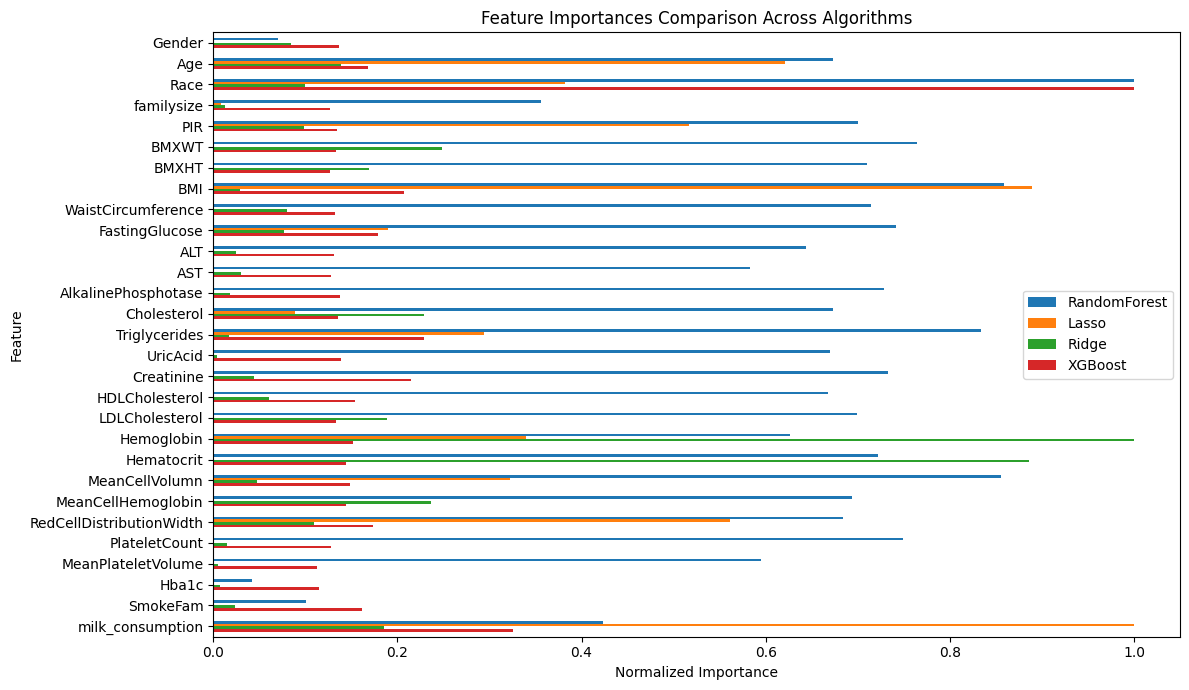

                     Feature  RandomForest     Lasso     Ridge   XGBoost
2                       Race      1.000000  0.382028  0.099582  1.000000
7                        BMI      0.858403  0.889330  0.028674  0.206785
21            MeanCellVolumn      0.855453  0.321868  0.047306  0.148751
14             Triglycerides      0.833470  0.294039  0.017347  0.229033
5                      BMXWT      0.763876  0.000000  0.248790  0.133412
24             PlateletCount      0.749664  0.000000  0.015052  0.127626
9             FastingGlucose      0.741543  0.190059  0.077218  0.179183
16                Creatinine      0.732838  0.000000  0.044681  0.214405
12       AlkalinePhosphotase      0.728477  0.000000  0.017893  0.137445
20                Hematocrit      0.722326  0.000000  0.886486  0.144367
8         WaistCircumference      0.714766  0.000000  0.079980  0.132601
6                      BMXHT      0.709497  0.000000  0.168833  0.127313
4                        PIR      0.699860  0.51686

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt

# Load dataset

X = df.drop(columns=['label', 'YearStart', 'YearID', 'VitaminD'])  # Drop non-features
y = df['label'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standardize for linear models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_importance = rf.feature_importances_

# 2. Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_train)
lasso_importance = np.abs(lasso.coef_)

# 3. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_train)
ridge_importance = np.abs(ridge.coef_)

# 4. XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_importance = xgb_model.feature_importances_

# Aggregate results into a DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'XGBoost': xgb_importance
})

# Normalize for visualization
for col in ['RandomForest', 'Lasso', 'Ridge', 'XGBoost']:
    importance_df[col] = importance_df[col] / importance_df[col].max()

# Plot top 10 features by Random Forest
top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']

importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 7))
plt.title("Feature Importances Comparison Across Algorithms")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print all results
print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20076 entries, 0 to 23837
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    20076 non-null  float64
 1   Age                       20076 non-null  float64
 2   Race                      20076 non-null  float64
 3   familysize                20076 non-null  float64
 4   PIR                       20076 non-null  float64
 5   BMXWT                     20076 non-null  float64
 6   BMXHT                     20076 non-null  float64
 7   BMI                       20076 non-null  float64
 8   WaistCircumference        20076 non-null  float64
 9   FastingGlucose            20076 non-null  float64
 10  ALT                       20076 non-null  float64
 11  AST                       20076 non-null  float64
 12  AlkalinePhosphotase       20076 non-null  float64
 13  Cholesterol               20076 non-null  float64
 14  Triglycerid

In [35]:
df.drop(columns=['Cholesterol', 'BMXWT', 'BMXHT', "YearID"], inplace=True)

# save to csv
df.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\processed_train.csv', index=False)

In [34]:
df.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'Hba1c', 'VitaminD', 'SmokeFam',
       'milk_consumption', 'YearStart', 'label'],
      dtype='object')

## Simple test preparation

In [36]:
df1 = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\test.csv')

In [37]:
remove_columns = ['Cholesterol', 'BMXWT', 'BMXHT', "YearID","HBsAg"]
df1.drop(columns = remove_columns,inplace=True)

In [38]:
df1.dropna(inplace=True)

In [39]:
df1['Hba1c'].isna().sum()

np.int64(0)

In [40]:
df1['Hba1c'] = df1['Hba1c'].apply(isDiabete)

In [41]:
df1.to_csv(r'C:\mydata\G8Vitamin\data\final\31082025_fill_with_median\processed_test.csv', index=False)